# A Regressão Linear
- Se temos um conjunto de pontos como o mostrado abaixo, podemos traçar qualquer reta que passa por esses pontos
    - Nesse caso, vamos traçar uma reta y = x
<img src="../../../images/linear_regression/linear_regression_example.png" style="width: 400px;"/>
- Infinitas retas podem ser traçadas, mas qual seria <font color='blue'>**a melhor reta**</font> que passa por esses pontos?
<img src="../../../images/linear_regression/mutiple_linear_regression_example.png" style="width: 400px;"/>
- <font color='blue'>**a melhor reta:**</font> o que seria "melhor"?
    - Para definir esse conceito podemos, por exemplo, verificar a distância de cada ponto a essa reta vermelha e escolher baseado nessa distância
<img src="../../../images/linear_regression/linear_regression_dot_distance.png" style="width: 500px;"/>
- A **regressão vai traçar essa reta para <font color='blue'>minimizar a soma dos erros ao quadrado**</font>, segundo a própria documentação
    - https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares
<img src="../../../images/linear_regression/linear_regression_real_x_planned.png" style="width: 400px;"/>

In [6]:
# Podemos considerar esses dados abaixo
import pandas as pd

data = pd.DataFrame({
    'X': [1, 2, 3, 4, 5],
    'Y': [1.3, 1.8, 3.5, 4, 4.6]
})

data.head(2)

,X,Y
0,1,1.3
1,2,1.8


In [9]:
data.head(3)

,X,Y,y_line
0,1,1.3,1
1,2,1.8,2
2,3,3.5,3


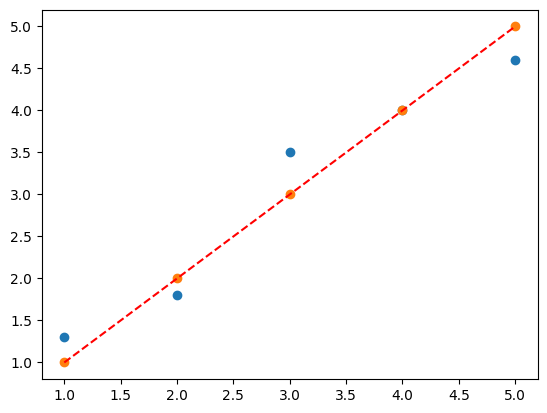

In [53]:
# Visualizando esses pontos graficamente, podemos traçar uma reta que passa por esse pontos
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(data.X, data.Y)
ax.plot(data.X, data.y_trendline, '--r')
ax.scatter(data.X, data.y_trendline)

plt.show()

In [52]:
# Nessa reta vermelha, fizemos que y = x, então podemos escrever o y_reta como
data['y_trendline'] = data.X

- **Vamos usar a regressão linear para traçar a melhor reta que passa por esses pontos**
    - https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression

In [21]:
# Importando a regressão linear
from sklearn.linear_model import LinearRegression

In [22]:
# Criando o regressor
reg = LinearRegression().fit(data.X.values.reshape(-1, 1), data.Y)

In [33]:
# Visualizando o coeficiente angular
a = reg.coef_

In [34]:
# coeficiente linear
b = reg.intercept_

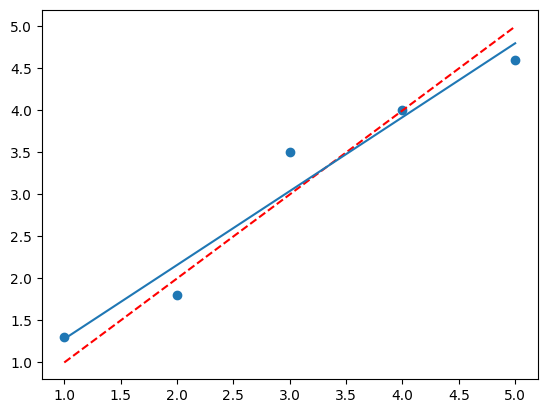

In [54]:
# Visualizando graficamente
fig, ax = plt.subplots()

ax.scatter(data.X, data.Y)
ax.plot(data.X, data.y_trendline, '--r')

x = data.X.values
y = a * x + b
ax.plot(x, y)

plt.show()

In [49]:
# Fazendo a previsão e adicionando na base
data['y_pred'] = reg.predict(data.X.values.reshape(-1, 1))

In [58]:
data

,X,Y,y_line,y_pred,y_trendline,error_trendline,trendline_error,pred_error
0,1,1.3,1,1.28,1,0.09,0.09,0.0004
1,2,1.8,2,2.16,2,0.04,0.04,0.1296
2,3,3.5,3,3.04,3,0.25,0.25,0.2116
3,4,4.0,4,3.92,4,0.00,0.00,0.0064
4,5,4.6,5,4.80,5,0.16,0.16,0.0400


In [57]:
# Calculando o erro da reta vermelha e da regressão
data['trendline_error'] = (data.Y - data.y_trendline) ** 2
data['pred_error'] = (data.Y - data.y_pred) ** 2

In [66]:
# Verificando essa base e a soma do erro
data[['trendline_error', 'pred_error']].mean()

trendline_error    0.1080
pred_error         0.0776
dtype: float64

- Podemos utilizar o erro médio absoluto e o erro médio quadrático do próprio scikit-learn para calcular esses erros
    - https://scikit-learn.org/stable/modules/classes.html#sklearn-metrics-metrics

In [61]:
# Além disso, também podemos usar o erro médio absoluto e o erro médio quadrático do próprio scikit-learn
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [65]:
# Visualizando o resultado da previsão
print(mean_absolute_error(data.Y, data.y_trendline))
print(mean_squared_error(data.Y, data.y_trendline))

print(mean_absolute_error(data.Y, data.y_pred))
print(mean_squared_error(data.Y, data.y_pred))

0.2800000000000001
0.10800000000000005
0.22400000000000003
0.07760000000000003


### Usando a Regressão Linear de forma prática
- **Vamos utilizar o dataset de casas da Califórnia**
    - https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

In [70]:
# Importando o dataset
from sklearn.datasets import fetch_california_housing

housing_data = fetch_california_housing()

In [71]:
# Visualizando
housing_data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [76]:
# Transformando em um DataFrame
houses = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
houses['MedHouseVal'] = housing_data.target

In [77]:
# Visualizando o dataframe
houses

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


- **Regressão Linear Simples**

In [132]:
# Separando X e Y
X = houses.MedInc
y = houses.MedHouseVal

- Separando nossa base em treino e teste para criarmos o modelo
    - https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [133]:
# Separando em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [134]:
# Usando a regressão linear
reg = LinearRegression().fit(X_train.values.reshape(-1, 1), y_train)

In [135]:
# Avaliando o erro
y_pred = reg.predict(X_test.values.reshape(-1, 1))

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.6265986453094173
0.7028461448540976


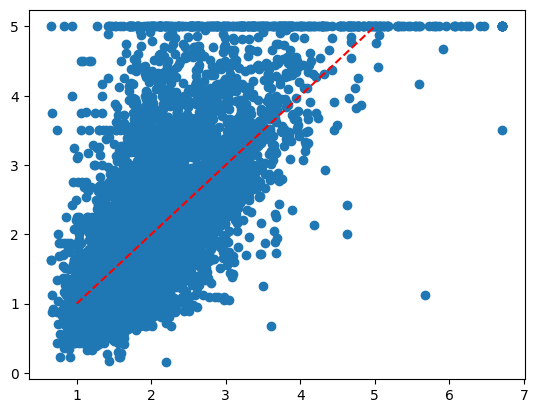

In [136]:
# Visualizando a relação do y_test com o y_pred
fig, ax = plt.subplots()

ax.scatter(y_pred, y_test)
ax.plot([1,5], [1,5], '--r')

plt.show()

<a id='linear_multipla'></a>
- **Regressão Linear Múltipla**

- Primeiro fazendo para apenas duas variáveis

In [139]:
# Separando X e Y
X = houses.drop('MedHouseVal', axis=1)
y = houses['MedHouseVal']

In [140]:
# Separando em treino e teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [141]:
# Usando a regressão linear
reg = LinearRegression().fit(X_train, y_train)

In [142]:
# Da mesma forma, também vamos ter o coef_
reg.coef_

array([ 4.44870466e-01,  9.55004561e-03, -1.21991503e-01,  7.79144696e-01,
       -7.68990809e-08, -3.29948505e-03, -4.19131153e-01, -4.34103468e-01])

In [143]:
# E o intercept_
reg.intercept_

np.float64(-37.08201093908007)

In [144]:
# Avaliando o erro
y_pred = reg.predict(X_test.values)

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.5295710106684451
0.5369686543372462


D:\Users\Patrick\PycharmProjects\MachineLearningAlgorithms\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


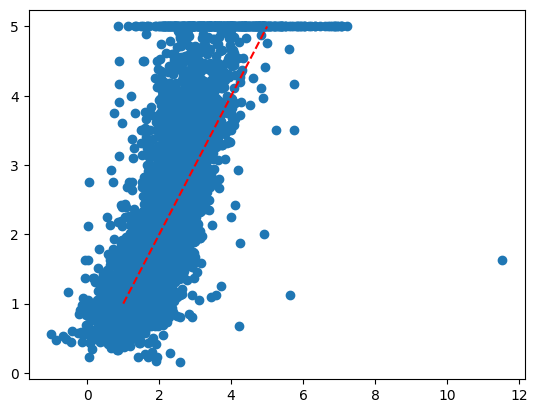

In [149]:
# Visualizando a relação do y_test com o y_pred
fig, ax = plt.subplots()

ax.scatter(y_pred, y_test)
ax.plot([1,5], [1,5], '--r')

plt.show()

- Podemos [voltar](#linear_multipla) e considerar qualquer coluna para o modelo